
# Financial Sales Forecasting Model Training

This notebook trains a **Revenue Forecasting Model** for the Pharma Analytics Dashboard.

### Model Details
- Algorithm: Prophet Time-Series Forecasting
- Inputs: Historical Revenue, Date Variables
- Output: Daily Predicted Revenue (IQD) with Confidence Interval
- Forecast Horizon: 30 Days


In [1]:

!pip install prophet joblib pandas matplotlib


In [2]:

import pandas as pd
from prophet import Prophet
import joblib
import matplotlib.pyplot as plt



## Upload Dataset

Upload the file:
pioneer_pharma_ideal_dataset_70000_rows.csv

In [4]:

from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

## Load Dataset

In [ ]:

df = pd.read_csv("/content/pioneer_pharma_ideal_dataset_70000_rows.csv")

df.head()

,order_id,order_date,sku_id,product_name,batch_id,region,warehouse,transaction_type,quantity,unit_price_iqd,revenue_iqd,expiry_date,production_status
0,SO-100000,2024-04-12,SKU-1007,ATRANEER 10mg/ml Injection,BATCH-771155,Basra,WH 1-50,Sale,232,1100,255200,2025-02-07,Completed
1,SO-100001,2025-04-11,SKU-1003,NAPRON 500mg Tablet,BATCH-621430,Mosul,WH 1-50,Sale,204,450,91800,2026-09-16,Released
2,SO-100002,2025-05-06,SKU-1007,ATRANEER 10mg/ml Injection,BATCH-427069,Baghdad-Karkh,WH 1-70,Sale,187,1100,205700,2027-02-04,In Progress
3,SO-100003,2024-11-09,SKU-1004,SITAVIA Plus 50/1000mg,BATCH-521909,Baghdad-Rusafa,WH 2-400,Sale,201,900,180900,2025-11-13,In Progress
4,SO-100004,2025-11-17,SKU-1005,SITAVIA 100mg Tablets,BATCH-691723,Baghdad-Karkh,WH 1-70,Sale,201,850,170850,2026-06-05,In Progress


## Convert Date Column

In [6]:

df["order_date"] = pd.to_datetime(df["order_date"])


## Filter Only Sales Transactions

In [7]:

df = df[df["transaction_type"] == "Sale"]


## Aggregate Daily Revenue

In [8]:

daily_revenue = df.groupby("order_date")["revenue_iqd"].sum().reset_index()

daily_revenue.head()


,order_date,revenue_iqd
0,2024-01-01,11872800
1,2024-01-02,13787800
2,2024-01-03,12006800
3,2024-01-04,13570400
4,2024-01-05,14518100


## Prepare Data for Prophet

In [9]:

daily_revenue = daily_revenue.rename(columns={
    "order_date": "ds",
    "revenue_iqd": "y"
})

daily_revenue.head()


,ds,y
0,2024-01-01,11872800
1,2024-01-02,13787800
2,2024-01-03,12006800
3,2024-01-04,13570400
4,2024-01-05,14518100


## Train Forecast Model

In [10]:

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily_revenue)


## Generate 30 Day Forecast

In [11]:

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.tail()


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
814,2026-03-25,1.296767e+07,1.049496e+07,1.459240e+07,1.296764e+07,1.296771e+07,-457291.737503,-457291.737503,-457291.737503,-140546.905705,-140546.905705,-140546.905705,-316744.831798,-316744.831798,-316744.831798,0.0,0.0,0.0,1.251038e+07
815,2026-03-26,1.296793e+07,1.063743e+07,1.460587e+07,1.296790e+07,1.296796e+07,-446816.386562,-446816.386562,-446816.386562,-140663.985383,-140663.985383,-140663.985383,-306152.401179,-306152.401179,-306152.401179,0.0,0.0,0.0,1.252111e+07
816,2026-03-27,1.296818e+07,1.046659e+07,1.441574e+07,1.296815e+07,1.296822e+07,-477226.899004,-477226.899004,-477226.899004,-187152.284748,-187152.284748,-187152.284748,-290074.614256,-290074.614256,-290074.614256,0.0,0.0,0.0,1.249095e+07
817,2026-03-28,1.296844e+07,1.085433e+07,1.488848e+07,1.296840e+07,1.296848e+07,-39776.817858,-39776.817858,-39776.817858,229128.495023,229128.495023,229128.495023,-268905.312881,-268905.312881,-268905.312881,0.0,0.0,0.0,1.292866e+07
818,2026-03-29,1.296869e+07,1.117977e+07,1.513196e+07,1.296865e+07,1.296874e+07,108521.649466,108521.649466,108521.649466,351668.745475,351668.745475,351668.745475,-243147.096009,-243147.096009,-243147.096009,0.0,0.0,0.0,1.307721e+07


## Forecast Visualization

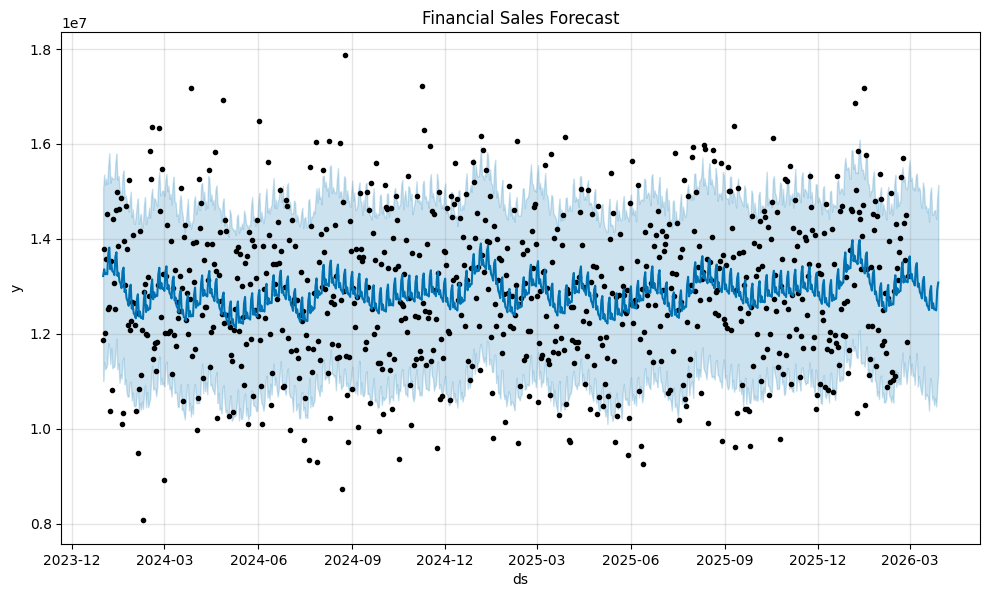

In [12]:

fig = model.plot(forecast)

plt.title("Financial Sales Forecast")

plt.show()


## Save Trained Model

In [13]:

joblib.dump(model, "revenue_forecast_model.pkl")


['revenue_forecast_model.pkl']

In [14]:

from google.colab import files
files.download("revenue_forecast_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import joblib

model = joblib.load("revenue_forecast_model.pkl")

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
814,2026-03-25,1.296767e+07,1.056174e+07,1.446506e+07,1.296765e+07,1.296770e+07,-457291.737503,-457291.737503,-457291.737503,-140546.905705,-140546.905705,-140546.905705,-316744.831798,-316744.831798,-316744.831798,0.0,0.0,0.0,1.251038e+07
815,2026-03-26,1.296793e+07,1.063645e+07,1.454579e+07,1.296790e+07,1.296796e+07,-446816.386562,-446816.386562,-446816.386562,-140663.985383,-140663.985383,-140663.985383,-306152.401179,-306152.401179,-306152.401179,0.0,0.0,0.0,1.252111e+07
816,2026-03-27,1.296818e+07,1.060205e+07,1.451784e+07,1.296815e+07,1.296822e+07,-477226.899004,-477226.899004,-477226.899004,-187152.284748,-187152.284748,-187152.284748,-290074.614256,-290074.614256,-290074.614256,0.0,0.0,0.0,1.249095e+07
817,2026-03-28,1.296844e+07,1.089118e+07,1.498897e+07,1.296840e+07,1.296847e+07,-39776.817858,-39776.817858,-39776.817858,229128.495023,229128.495023,229128.495023,-268905.312881,-268905.312881,-268905.312881,0.0,0.0,0.0,1.292866e+07
818,2026-03-29,1.296869e+07,1.101286e+07,1.516246e+07,1.296866e+07,1.296873e+07,108521.649466,108521.649466,108521.649466,351668.745475,351668.745475,351668.745475,-243147.096009,-243147.096009,-243147.096009,0.0,0.0,0.0,1.307721e+07
